In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, 
    GlobalAveragePooling1D, MultiHeadAttention, Add , BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau , ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import L2

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

2025-12-15 04:42:08.280737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765773728.610483      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765773728.705627      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# LOAD AND EXPLORE DATA

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/glove6b100dtxt/glove.6B.100d.txt
/kaggle/input/nn-26-review-sentiment-classification/sample_submission.csv
/kaggle/input/nn-26-review-sentiment-classification/train.csv
/kaggle/input/nn-26-review-sentiment-classification/test.csv


In [3]:
df=pd.read_csv("/kaggle/input/nn-26-review-sentiment-classification/train.csv")

In [4]:
pd.set_option('display.max_colwidth', None)

In [5]:
df.head(10)['text']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [6]:
df.shape

(7000, 3)

check null and duplicates

In [7]:
df.isnull().sum()

id        0
text      0
review    0
dtype: int64

In [8]:
df = df.drop('id', axis=1)

we found text number 4372   and 9680 is same text same review so deside to drop one 

## Remove duplicates

In [9]:
df.duplicated().sum()

1

In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

0

TEXT PREPROCESSING

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', 'url', text) 
    text = re.sub(r'\s+', ' ', text)  
    text = text.strip()
    return text

In [13]:
df['text'] = df['text'].apply(clean_text)

In [14]:
df.head(10)['text']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

# TRAIN-VAL SPLIT

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    df['text'], 
    df['review'],
    test_size=0.2,
    random_state=42,
    stratify=df['review']
)

# HANDLE CLASS IMBALANCE WITH SMART SAMPLING

In [16]:
df['review'].value_counts()

review
Very good    2469
Excellent    2335
Good         1024
Bad           647
Very bad      524
Name: count, dtype: int64

In [17]:
def balance_dataset(X, y,target=1000 ):
    """
    Balance dataset with configurable strategy
    """
    df_train = pd.concat([X, y], axis=1)
    class_counts = y.value_counts()
    
    
    balanced_dfs = []
    for label, group in df_train.groupby(y.name):
        current_size = len(group)
        
        if current_size > target:
            # Downsample
            sampled = group.sample(n=target, random_state=42)
        else:
            sampled = group 
        
        balanced_dfs.append(sampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=42)
    
    return balanced_df[X.name], balanced_df[y.name]

In [18]:
X_train, y_train = balance_dataset(X_train, y_train,target = 1500)

# sentence lenth 

In [19]:
hist = {}

for text in df['text']:
    
    freq = len(text) 
    
    if freq in hist:
        hist[freq] += 1
    else:
        hist[freq] = 1 

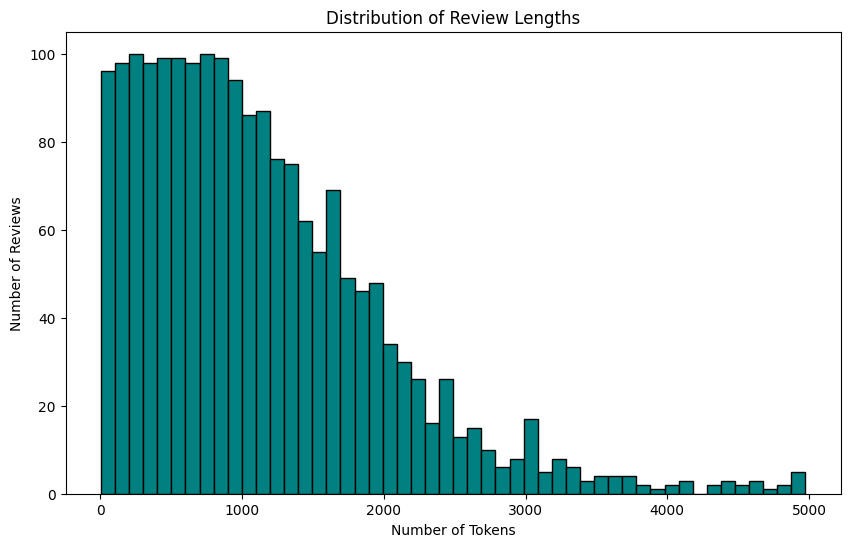

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(hist, bins=50, color='teal', edgecolor='black')

plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Reviews')
plt.show()

In [21]:
lengths = []
for length, count in hist.items():
    lengths.extend([length] * count)

lengths = np.array(lengths)

mean = lengths.mean()
median = np.median(lengths)
min_val=min(hist.keys())
max_val=max(hist.keys())
p70 = np.percentile(lengths, 70)
p80 = np.percentile(lengths, 80)
p90 = np.percentile(lengths, 90)
p95 = np.percentile(lengths, 95)

print("Mean:", mean)
print("Median:", median)
print("Min length:", min_val)
print("Max length:", max_val)
print("70th percentile:", p70)
print("80th percentile:", p80)
print("90th percentile:", p90)
print("95th percentile:", p95)


Mean: 700.3859122731819
Median: 531.0
Min length: 4
Max length: 4975
70th percentile: 817.5999999999995
80th percentile: 1054.0
90th percentile: 1449.0
95th percentile: 1880.199999999999


# one hot encoding

In [22]:
import numpy as np

# 1. Initialize Encoder
# sparse_output=False creates a dense numpy array (like to_categorical)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. Fit and Transform
# Reshape to (-1, 1) because OneHotEncoder expects 2D input
y_train_cat = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_val_cat = ohe.transform(y_val.values.reshape(-1, 1))

# 3. Get Class Info
num_classes = len(ohe.categories_[0])
classes = ohe.categories_[0]

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")
print(f"y_train_cat shape: {y_train_cat.shape}")

Number of classes: 5
Classes: ['Bad' 'Excellent' 'Good' 'Very bad' 'Very good']
y_train_cat shape: (4756, 5)


# GENERATE EMBEDDINGS USING SENTENCE-TRANSFORMERS

In [23]:
embedding_model = SentenceTransformer('all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
X_train_emb = embedding_model.encode(
    X_train.tolist(), 
    show_progress_bar=True,
    batch_size=32
)

Batches:   0%|          | 0/149 [00:00<?, ?it/s]

In [25]:
X_val_emb = embedding_model.encode(
    X_val.tolist(), 
    show_progress_bar=True,
    batch_size=32
)

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

In [26]:
embedding_dim = X_train_emb.shape[1]
# X_train_emb=X_train_emb.reshape(X_train_emb.shape[0],1,X_train_emb.shape[1])
# X_val_emb=X_val_emb.reshape(X_val_emb.shape[0],1,-1)

# BUILD TRANSFORMER CLASSIFIER

In [27]:
model = Sequential([
    Dense(256, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train_emb.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')
])


I0000 00:00:1765773814.857802      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14059 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [28]:
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
# from tensorflow.keras.models import Model
# from tensorflow.keras.regularizers import l1_l2
# from tensorflow.keras.constraints import max_norm

# def create_minimal_classifier(embedding_dim, num_classes):
#     inputs = Input(shape=(embedding_dim,))
#     # Single hidden layer with strong regularization
    
#     x = Dense(
#         128, 
#         activation='relu',
#         kernel_regularizer=l1_l2(l1=0.01, l2=0.01) )(inputs)
#     x = BatchNormalization()(x)
#     x = Dropout(0.7)(x)  
    
#     # Output layer
#     outputs = Dense(num_classes, activation='softmax')(x)
    
#     model = Model(inputs=inputs, outputs=outputs)
#     return model

In [29]:
# model = create_transformer_classifier(
#     embedding_dim=embedding_dim,
#     num_classes=5,
#     num_heads=4,      # Reduced from 8
#     ff_dim=128,       # Reduced from 256
#     dropout_rate=0.3,
#     l2_reg=1e-4
# )
# model.summary()

In [30]:
model.compile(
    optimizer=Adam(learning_rate=2e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# class weights

In [31]:
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train_int),
#     y=y_train_int
# )
# class_weight_dict = dict(enumerate(class_weights))

In [32]:
# for i, class_name in enumerate(le.classes_):
#     print(f"{i:<5} | {class_name:<20} ")

In [33]:
class_weight_dict={
    0:2.5,
    1:1.5,
    2:2,
    3:2,
    4:2
}

 # CALLBACKS

In [34]:
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',  
    monitor='val_loss',
    save_best_only=True,        
    mode='min'
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

In [36]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

# TRAIN MODEL

In [37]:
history = model.fit(
    X_train_emb, y_train_cat,
    validation_data=(X_val_emb, y_val_cat),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr,checkpoint],
    verbose=1,
    class_weight=class_weight_dict
)


Epoch 1/200


I0000 00:00:1765773818.118223     130 service.cc:148] XLA service 0x785d14118fd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765773818.119552     130 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765773818.460632     130 cuda_dnn.cc:529] Loaded cuDNN version 90300


65/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2633 - loss: 3.6458

I0000 00:00:1765773820.557761     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.2683 - loss: 3.6318 - val_accuracy: 0.3521 - val_loss: 2.0054 - learning_rate: 2.0000e-04
Epoch 2/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3339 - loss: 3.3421 - val_accuracy: 0.3764 - val_loss: 1.8512 - learning_rate: 2.0000e-04
Epoch 3/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3615 - loss: 3.1156 - val_accuracy: 0.4221 - val_loss: 1.7166 - learning_rate: 2.0000e-04
Epoch 4/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4096 - loss: 2.8967 - val_accuracy: 0.4793 - val_loss: 1.6560 - learning_rate: 2.0000e-04
Epoch 5/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4221 - loss: 2.7936 - val_accuracy: 0.4836 - val_loss: 1.6025 - learning_rate: 2.0000e-04
Epoch 6/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4489 - loss: 2.7107 - val_accuracy: 0.4864 - val_loss: 1.5551 - learning_rate: 2.0000e-04
Epoch 7/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4473 - loss: 2.6

# EVALUATE MODEL

## Training predictions

In [39]:
y_train_pred = model.predict(X_train_emb, verbose=0)
y_train_pred_classes = np.argmax(y_train_pred, axis=1)

In [40]:
y_val_pred = model.predict(X_val_emb, verbose=0)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

In [45]:
y_train_true = np.argmax(y_train_cat, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

## Metrics

In [46]:
print("\nTRAINING SET:")
print(classification_report(y_train_true, y_train_pred_classes, 
                          target_names=ohe.categories_[0]))


TRAINING SET:
              precision    recall  f1-score   support

         Bad       0.58      0.68      0.63       518
   Excellent       0.74      0.68      0.71      1500
        Good       0.66      0.47      0.55       819
    Very bad       0.76      0.79      0.78       419
   Very good       0.60      0.71      0.65      1500

    accuracy                           0.66      4756
   macro avg       0.67      0.67      0.66      4756
weighted avg       0.67      0.66      0.66      4756



In [47]:
# Validation metrics
print("\nVALIDATION SET:")
print(classification_report(y_val_true, y_val_pred_classes, 
                          target_names=ohe.categories_[0]))


VALIDATION SET:
              precision    recall  f1-score   support

         Bad       0.44      0.52      0.48       129
   Excellent       0.65      0.62      0.63       467
        Good       0.45      0.36      0.40       205
    Very bad       0.54      0.58      0.56       105
   Very good       0.55      0.59      0.57       494

    accuracy                           0.56      1400
   macro avg       0.53      0.53      0.53      1400
weighted avg       0.56      0.56      0.55      1400



# VISUALIZE RESULTS

## Model Accuracy Plot

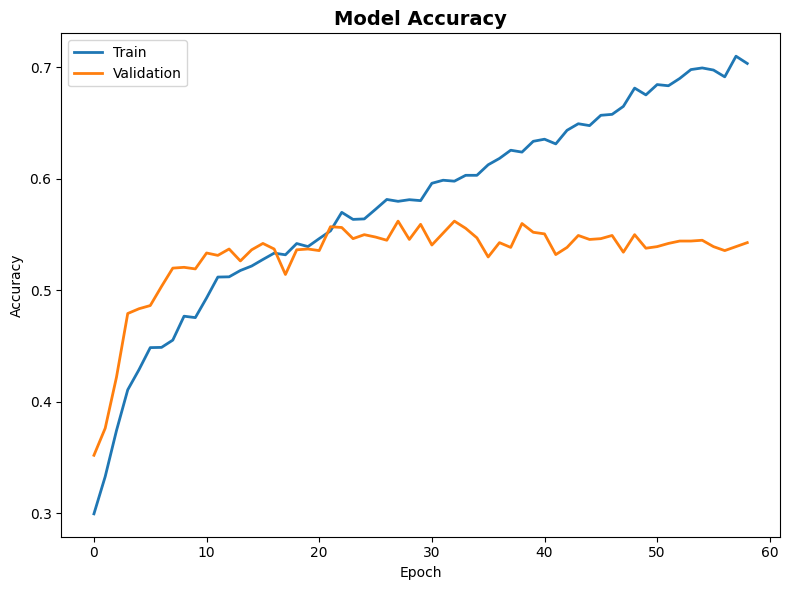

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Model Loss Plot

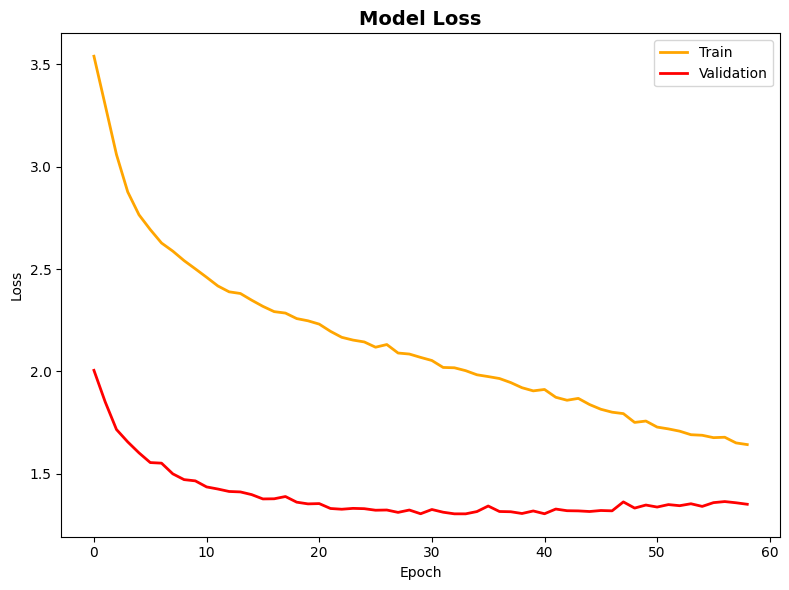

In [49]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train', color='orange', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', color='red', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
cm_train = confusion_matrix(y_train_true, y_train_pred_classes)
cm_val = confusion_matrix(y_val_true, y_val_pred_classes)

## Training Confusion


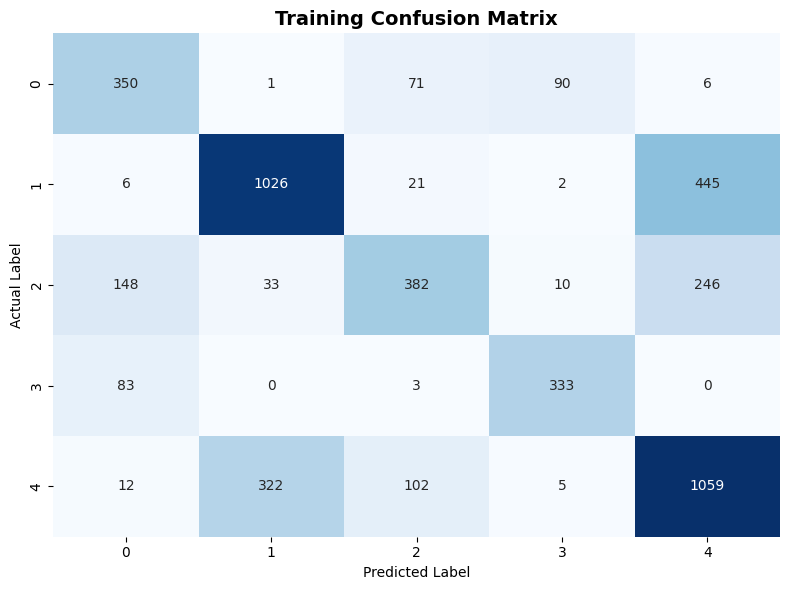

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Training Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


## Validation Confusion

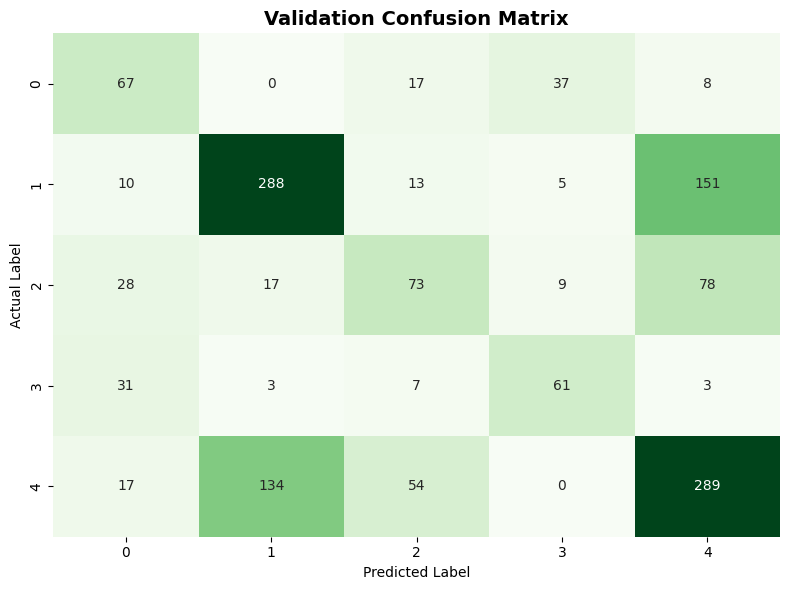

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# perdict on test

In [54]:
test_df=pd.read_csv("/kaggle/input/nn-26-review-sentiment-classification/test.csv")

In [55]:
test_id=test_df['id']

In [56]:
test_df['text'] = test_df['text'].apply(clean_text)

In [57]:
X_test_emb = embedding_model.encode(
    test_df['text'], 
    show_progress_bar=True,
    batch_size=32
)

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [58]:
test_predict = model.predict(X_test_emb)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [59]:
predicted_indices = np.argmax(test_predict, axis=1)
predicted_labels = ohe.categories_[0][predicted_indices]

In [60]:
submission = pd.DataFrame({
    'id': test_id,           
    'review': predicted_labels
})

submission.to_csv('submission.csv', index=False)
submission.head(10)

,id,review
0,298,Very good
1,4153,Very good
2,5359,Very good
3,7734,Very good
4,3283,Very good
5,9321,Excellent
6,4945,Excellent
7,6246,Very good
8,8882,Very good
9,5839,Bad


In [61]:
model.save('best_model_NLP.keras')